---
title: "NFL Fourth-Down Decisions"

format: html
embed-resources: true
echo: false
---


# **Introduction**

## Background 

In American football, two teams of eleven players compete to move a ball into the opposing team’s end zone to score points. The game is divided into four quarters, and each team has four chances (called “downs”) to move the ball at least ten yards. If they succeed, they get another set of downs. If they fail, the other team gains possession. The game is strategic, with plays designed to gain yards or stop the opposing team.

A key decision occurs on the fourth down, where the team has three options: 

- **Punt**:  the safest option, giving the ball to the other team but pushing them farther from the end zone. 

- **Kick a field goal**: offers a low-risk, low-reward chance to score, but it means losing the opportunity for a touchdown.

- **"Go for it"**: the riskiest option, where the team tries to move the ball the remaining distance to keep their drive alive. If they fail, the opposing team gets better field position, which could lead to a quick score. Deciding whether to "go for it" depends on factors like the game situation, field position, and score. 

Recently, more teams have been taking these risks to be more aggressive in their play calling.

## Purpose

- This report entails the procedure, summary, and discussion of the model development for the **front office of [this] NFL Team**. 

- This model estimates the probability that an attempt to convert a fourth down is successful, given information such as yards-to-go, yards-to-goal, and the type of play (run or pass) considered. 

-  This model will be used within a larger system that allows the offensive coordinator to evaluate play-calling decisions and how they affect the overall probability of winning the game.


# **Methods:** Data Description & Preparation

### Description

- The dataset consists of historical fourth-down conversion attempts in the NFL. 

- Each observation corresponds to a single play in which the offensive team elected to attempt a fourth-down conversion.

- The data include situational information describing the game state at the time of the play, such as distance to the first down, field position, and the type of play called.

### Response Variable
 
- `converted` (0,1): Indicator of whether the fourth-down conversion attempt was successful.

### Feature Variables

**Field Position and Distance:** Describe where the play occurs on the field and how far the offense must advance.

- `togo`: Yards required to convert the fourth down

- `yardline`: Distance in yards from the opponent’s end zone

**Play Characteristics:** Describe the strategic choice made by the offense.

- `play_type`: Run or pass


**Team Context:** Identify the teams involved in the play.

- `posteam`: Offensive team

- `defteam`: Defensive team

### Preprocessing Steps

- Converted the response variable to a binary numeric format,

- One-hot encoded categorical variables (`play_type`, `posteam`, `defteam`),

- Train–test split to evaluate generalization performance,

- Numeric variables preserved as continuous features,

- Training & testing feature matrices and response vectors.


In [ ]:
## IMPORTS 
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
## necessary liibraries 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.calibration import calibration_curve

In [ ]:
## Load data
football = pd.read_parquet(
    "https://lab.cs307.org/football/data/football.parquet"
)

In [ ]:
## Response variable (converted)
## Convert Yes / No -> 1 / 0
football["converted"] = (football["converted"] == "Yes").astype(int)

In [ ]:
## Train-test split
train_data = football[football["game_date"] < "2022-01-01"]
test_data  = football[football["game_date"] >= "2022-01-01"]

In [ ]:
## X and y
X_train = train_data.drop(columns=["converted", "game_date"])
y_train = train_data["converted"]

X_test = test_data.drop(columns=["converted", "game_date"])
y_test = test_data["converted"]

In [93]:
## Dataset shapes
num_train = X_train.shape[0]
num_test = X_test.shape[0]
num_features = X_train.shape[1]

print("Shape ", train_data.shape)
print("Training samples: ", num_train)
print("Testing samples:  ", num_test)
print("Number of features: ", num_features)

Shape  (1990, 7)
Training samples:  1990
Testing samples:   2563
Number of features:  5


In [ ]:
## Overall conversion probability (train)
overall_conversion_prob = y_train.mean()
print("Overall conversion probability (train): ", overall_conversion_prob)

Overall conversion probability (train):  0.5175879396984925



### Dataset Overview

| Metric | Value |
| :--- | :--- |
| Training Data Shape | (1990, 7) |
| Training Samples | 1990 |
| Number of Features | 5 |
| Overall Conversion Probability | 51.75% |



/var/folders/j7/3ys2ycwd7pb3m8w34ygdtyr00000gn/T/ipykernel_98632/4179595010.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("togo_bin")["converted"]


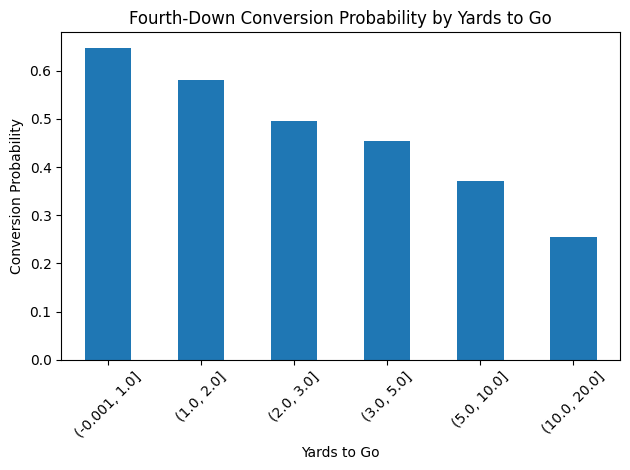

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Bin yards-to-go into football relevant groups
togo_bins = pd.cut(
    train_data["togo"],
    bins=[0, 1, 2, 3, 5, 10, 20],
    include_lowest=True
)

conversion_by_togo = (
    train_data
    .assign(togo_bin=togo_bins)
    .groupby("togo_bin")["converted"]
    .mean()
)

plt.figure()
conversion_by_togo.plot(kind="bar")
plt.ylabel("Conversion Probability")
plt.xlabel("Yards to Go")
plt.title("Fourth-Down Conversion Probability by Yards to Go")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Exploratory Data Overview**


From the figure above, we observe: 

- Fourth-down conversion probability declines as yards-to-go increases implies strong negative relationship between distance and success.

- When the yards is short ($\leq$ $1$ yard), conversion is at the highest rate (above $60$%); medium length yards (around $2-5$) show  moderate success.

- When yards is over $10$, attempts have a much lower conversion rate (below $30$%), reflecting higher risk.

In summary, yards-to-go has a clear and consistent relationship with fourth-down success. Because the probability of converting changes noticeably across different distances, a predictive model can learn these patterns from the data rather than relying on fixed rules. 

Including additional game-state variables may help the model make more accurate probability estimates in similar situations.

# **Methods:** Model Development

## Model Selection

- The goal of this model is to estimate calibrated probabilities of fourth-down conversion to assist in making decisions. Reliable probability estimates are essential when comparing the expected outcomes of different decisions in the football world.

- A logistic regression model was selected as the base classifier due to its stability and interpretability. Team identifiers were encoded using target encoding to find patterns within specific teams. To further improve probability reliability, we then utilized CalibratedClassifierCV with sigmoid calibration.


In [96]:
# function to calculate the calibration error
def calibration_error(y_true, y_prob, type="expected", n_bins=10):
    """
    Compute calibration error of a binary classifier.

    The calibration error measures the aggregated difference between
    the average predicted probabilities assigned to the positive class,
    and the frequencies of the positive class in the actual outcome.

    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
        True targets of a binary classification task.

    y_prob : array-like of (n_samples,)
        Estimated probabilities for the positive class.

    type : {'expected', 'max'}, default='expected'
        The expected-type is the Expected Calibration Error (ECE), and the
        max-type corresponds to Maximum Calibration Error (MCE).

    n_bins : int, default=10
       The number of bins used when computing the error.

    Returns
    -------
    score : float
        The calibration error.
    """

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    binids = np.searchsorted(bins[1:-1], y_prob)

    bin_sums = np.bincount(binids, weights=y_prob, minlength=len(bins))
    bin_true = np.bincount(binids, weights=y_true, minlength=len(bins))
    bin_total = np.bincount(binids, minlength=len(bins))

    nonzero = bin_total != 0
    prob_true = bin_true[nonzero] / bin_total[nonzero]
    prob_pred = bin_sums[nonzero] / bin_total[nonzero]

    if type == "max":
        calibration_error = np.max(np.abs(prob_pred - prob_true))
    elif type == "expected":
        bin_error = np.abs(prob_pred - prob_true) * bin_total[nonzero]
        calibration_error = np.sum(bin_error) / len(y_true)

    return calibration_error


In [ ]:
## Column groups for football
numeric_cols = ["togo", "yardline"]
low_card_cat = ["play_type"]
high_card_cat = ["posteam", "defteam"]

In [ ]:
## TargetEncoder
from sklearn.preprocessing import TargetEncoder
te = TargetEncoder(smooth="auto", random_state=42)

In [ ]:
# Preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

lowcat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", 
                             sparse_output=False))
])

highcat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("target", te)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("lowcat", lowcat_transformer, low_card_cat),
        ("highcat", highcat_transformer, high_card_cat),
    ],
    remainder="drop"
)

In [ ]:
## Base model: Logistic Regression
base_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(
        solver="lbfgs",
        max_iter=500,
        C=1.0,
        class_weight=None,   
        random_state=42
    ))
])

In [ ]:
## Calibrated model (sigmoid)
calibrated_model = CalibratedClassifierCV(
    estimator=base_model,
    method="sigmoid",
    cv=5
)

In [ ]:
## Fit model
calibrated_model.fit(X_train, y_train)

## Predict proba
y_pred_proba = calibrated_model.predict_proba(X_test)[:, 1]

## Metrics
brier = brier_score_loss(y_test, y_pred_proba)
ll = log_loss(y_test, y_pred_proba)
ece = calibration_error(
    y_test,
    y_pred_proba,
    type="expected",
    n_bins=10
)
mce = calibration_error(
    y_test,
    y_pred_proba,
    type="max",
    n_bins=10
)
print("Brier Score: ",brier)
print("Log-loss: ",ll)
print("ECE Score: ", ece)
print("MCE Score: ", mce)
## Save model
joblib.dump(calibrated_model, "fourthdown_calibrated_logreg.joblib")

Brier Score:  0.2197724953176815
Log-loss:  0.6294227237384244
ECE Score:  0.035647358227670865
MCE Score:  0.0828601344337833


['fourthdown_calibrated_logreg.joblib']

## Calibration Metrics

The following metrics were used:


**Brier Score $=0.2197$**

- Measures mean squared error between predicted probabilities and observed outcomes.

- Lower values $\implies$ more accurate probability estimates.

- For fourth-down conversion data with a base rate near 50%, we consider a score $\leq 0.23$  acceptable.

**Log Loss** $=0.6294$

- Measures the negative log-likelihood of the observed outcomes.

- Penalizes confident but incorrect predictions more strongly than the Brier score.

- For modeling probability of binary (sports) outcomes, log loss $\leq 0.70$ is considered reasonable.

**Expected Calibration Error (ECE)** $=0.0356$

- Measures the average difference between the probabilities predicted by the model and the actual conversion rates.

- Lower values $\implies$ better overall calibration.

- We aimed for ECE $\leq 0.05$, indicating small average calibration error.

**Maximum Calibration Error (MCE)** $=0.0828$

- Measures the largest calibration error across probability bins.

- We aimed for MCE ≤ 0.10, so that no probability range is significantly miscalibrated.



## Step Descriptions


### 1. Feature Grouping

- Features were grouped into numeric (`togo`, `yardline`), low-cardinality categorical (`play_type`), and high-cardinality categorical (`posteam`, `defteam`) variables.

### 2. Preprocessing Pipeline

- Numeric features: missing values imputed with the median and standardized.


- Categorical features: missing values imputed and encoded using **one-hot encoding** (low-cardinality) or **target encoding** (high-cardinality teams).

- All preprocessing steps were combined using a `ColumnTransformer`.

### 3. Base Model

- A **logistic regression model** was used to estimate fourth-down conversion probabilities.

- **Regularization** was applied to reduce overfitting and improve generalization.

### 4. Probability Calibration

- Predicted probabilities were calibrated using **sigmoid** calibration.

- **Cross-validation** was used during calibration to improve reliability.

### 5. Prediction and Evaluation

- Conversion probabilities were generated on the test set.

- Model performance was evaluated using **Brier score**, **log loss**, Expected Calibration Error **(ECE)**, and Maximum Calibration Error **(MCE)**.


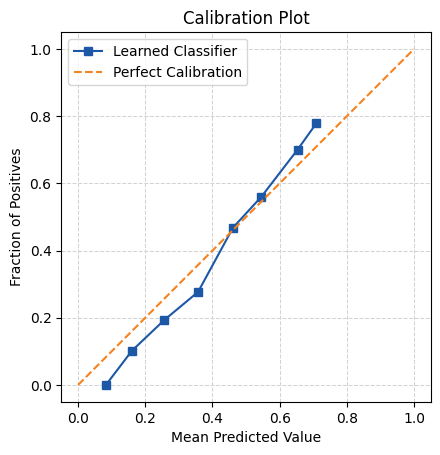

In [ ]:
# function to plot a calibration_plot
def plot_calibration_plot(y_true, y_prob):

    # generate "data" for calibration plot
    prob_true, prob_pred = calibration_curve(
        y_true,
        y_prob,
        n_bins=10,
        pos_label=1,
    )

    # create a figure and axis object with a specific size
    fig, ax = plt.subplots()

    # plot the calibration curve
    ax.plot(
        prob_pred,
        prob_true,
        "s-",
        label="Learned Classifier",
        color="#1D58A7",
    )

    # plot the diagonal "perfect" line
    ax.plot(
        [0, 1],
        [0, 1],
        "--",
        label="Perfect Calibration",
        color="#F5821E",
    )

    # set the plot title and axis labels
    ax.set_title("Calibration Plot")
    ax.set_xlabel("Mean Predicted Value")
    ax.set_ylabel("Fraction of Positives")

    # add a grid
    ax.grid(
        True,
        color="lightgrey",
        linewidth=0.75,
        linestyle="--",
    )

    # fix aspect ratio
    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    # show the legend
    ax.legend()

    # show the plot
    plt.show()


plot_calibration_plot(y_test, y_pred_proba )

## **Summary Figure**

- The calibration curve closely follows the diagonal line representing near perfect calibration.

- Predicted probabilities are overall consistent with observed conversion frequencies across most probability bins.

- Some small deviations appear at the lowest probability ranges, where the model slightly underestimates conversion rates (but these bins contain relatively few observations.)

- Considering the low ECE and MCE scores previously reported ($0.0356$ and $ 0.0828$, respectively), the summary figure alligns with this;  the figure confirms that the calibrated model produces reliable probability estimates.

# **Conclusion**

In this report, we built a model to **estimate the probability that a team successfully converts a fourth down** using basic game information such as yards to go, field position, play type, and team tendencies. 

The results showed that **yards to go** is the strongest factor influencing conversion success, with probabilities decreasing steadily as distance increases.

By combining **logistic regression** with **target encoding** and probability **calibration**, the model produces probability estimates that closely match what actually happens in the data. The low calibration error and the shape of the calibration plot indicate that the model’s predictions are generally *reliable*. 

While fourth-down outcomes remain uncertain, the model is still a useful reference for the NFL to make more informed fourth-down decision making.

# **Discussion**

### Benefits

- Model produces callibrated probalitilies rather than binary $(0,1)$ predictions. 

- Target encoding being used for the two team variables allows for us to look at team-specific tendencies.

- Aligned with real-world outcomes as the model is trained on historical NFL fourth-downs. 

- This model can be used within a larger system that allows the offensive coordinator to evaluate play-calling decisions and how they affect the overall probability of winning the game.

### Risks

- Predictions may be less reliable in rare situations. 

- Team tendencies can shift over time, so training on historical data may lose relevance.

### Limitations

- Assumes historical conversion behavior is representative of future decision-making.

- Calibration quality is dependent on having enough data in each probability range.